# Calculate coupling efficiency of misaligned extended source in the presence of jitter

In [18]:
import sys
from pathlib import Path

src_path = Path("/Users/tliu/oh_suppression/codes/src")

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from oh_suppression.coupling import *

In [19]:
from oh_suppression.point_source_coupling import *
from oh_suppression.coupling_vs_radius_sweeps import *
from oh_suppression.extended_source_coupling import *

In [11]:
import astropy.units as u
from astropy.modeling.models import Sersic2D
# Source: https://docs.astropy.org/en/stable/api/astropy.modeling.functional_models.Sersic2D.html

In [12]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import special #import jv, kv
# from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [13]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [14]:
from scipy.optimize import brentq
from scipy.optimize import fminbound

In [15]:
from dataclasses import dataclass
import pandas as pd

In [16]:
from joblib import Parallel, delayed
import os

In [20]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 
# fibre core radius
a = 5e-6 
# numerical aperture of fibre
NA = 0.1 

# Calculate the normalised frequency (V-number) of the fibre
V = 2 * pi * (a / lam0) * NA
print(f"V-number of the fibre: {V:.2f}")

V-number of the fibre: 2.09


In [21]:
V_max_single = 2.405 # The cutoff V-number for single-mode operation in a step-index fibre
a_max_single = V_max_single * lam0 / (2 * np.pi * NA)
print(f"Maximum core radius for single-mode operation: {a_max_single*1e6:.20f} microns")

Maximum core radius for single-mode operation: 5.74151457204012416469 microns


In [22]:
NA = 0.1
F_fibre = 1 / (2 * np.tan(np.arcsin(NA)))
Magnification = F_fibre / 49.9
F_focus = 49.9
D_M1 = 8.0
D_M1 = 8.0 # Diameter of the primary mirror in meters
D_obstruction = 1.0 # Diameter of the central obstruction in meters
alpha_vlt = D_obstruction / D_M1 # Ratio of the central obstruction to the primary mirror diameter
rad_to_arcsec = (180 / np.pi) * 3600
plate_scale_coude = rad_to_arcsec / (F_focus * D_M1)  # arcsec / metre at telescope focal plane
plate_scale_demag = plate_scale_coude / Magnification # arcsec / metre at the demagnified fibre input plane

In [46]:
Magnification

np.float64(0.09969813999064328)

In [49]:
# Focal length of the Coudé focus in meters according to VLT documentation 
f_coude = 399

In [23]:
print(f"Plate scale at the Coudé focus: {plate_scale_coude*1e-3:.2f} arcsec/mm")

Plate scale at the Coudé focus: 0.52 arcsec/mm


In [24]:
n_sersic = 3.335 # sersic index, n>0.36
Re_arcsec = 0.101 # half light radius in arcseconds
q_param = 0.514 # projected axis ratio of the galaxy, b/a, where b is the semi-minor axis and a is the semi-major axis. This is used to calculate the effective radius in the direction of the fibre input plane.
# PA = 0 # assumed to be 0 for simplicity, but can be adjusted based on the orientation of the galaxy in the sky.
PA_deg = -88.7
ellip = 1 - q_param # ellipticity of the galaxy, defined as 1 - (b/a)

In [25]:
# Sersic profile has a scaling constant b_n, for n>0.36, b_n can be approximated as b_n = 2n - 1/3 + 4/(405n) + 46/(25515n^2) + 131/(1148175n^3) 
# - 2194697/(30690717750n^4)
b_n = 2 * n_sersic - 1/3 + 4/(405*n_sersic) + 46/(25515*n_sersic**2) + 131/(1148175*n_sersic**3) - 2194697/(30690717750*n_sersic**4)

In [28]:
# Sersic2D?

In [29]:
# Fibre front grid in metres

r_max = 125e-6 # maximum radius of the CLADDING region to be considered in the 2D grid, in meters
n_grid = 1000 

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [30]:
FOV_test = plate_scale_demag * 2 * r_max
FOV_test_smf = plate_scale_demag * 2 * 5.7e-6
print(f"Test FOV: {FOV_test:.4f} arcsec")
print(f"Test FOV for SMF: {FOV_test_smf:.4f} arcsec")

Test FOV: 1.2956 arcsec
Test FOV for SMF: 0.0591 arcsec


In [31]:
# Angular grid for the Sersic profile, in radians

# angular_extent = 0.5 # arcsec (I should probably find the FOV of a 125e-6m light bucket)
angular_extent = 1.30/2 # arcsec, which is half of the FOV of a 125e-6m light bucket at the Coudé focus, based on the plate scale calculated above.

x_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)
y_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)

x_arcsec, y_arcsec = np.meshgrid(x_arcsec_1d, y_arcsec_1d)

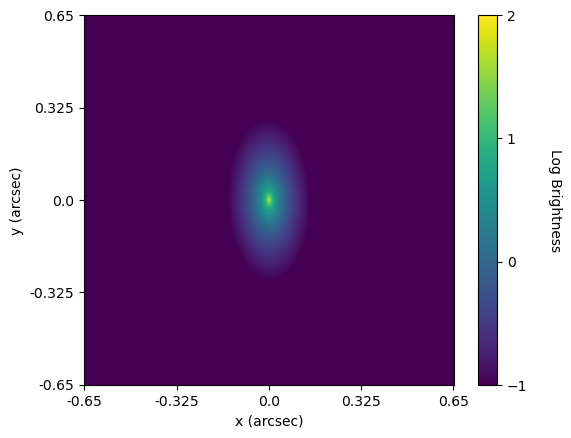

In [32]:
model_cent = Sersic2D(amplitude=1, r_eff = Re_arcsec, n = n_sersic, x_0=0, y_0=0, ellip=ellip, theta=np.radians(PA_deg))

# img is a numpy array of the Sersic profile evaluated at each point in the 2D grid defined by x_arcsec and y_arcsec. 
img = model_cent(x_arcsec, y_arcsec)
log_img = np.log10(img)

fig, ax = plt.subplots()
im = ax.imshow(log_img, origin='lower', interpolation='nearest',
               vmin=-1, vmax=2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Log Brightness', rotation=270, labelpad=25)
# Set ticks in arcseconds for the x and y axes
ax.set_xticks(np.linspace(0, n_grid-1, 5))
ax.set_xticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
ax.set_yticks(np.linspace(0, n_grid-1, 5))
ax.set_yticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
cbar.set_ticks([-1, 0, 1, 2])
plt.xlabel('x (arcsec)')
plt.ylabel('y (arcsec)')
plt.show()

In [34]:
# Only test for a single normalised frequency at r=5.7microns for my first test of decentred position
prepared_smf_mode_5p7micron = prepare_modes_2d(
                                x, y,
                                a=5.7e-6, 
                                NA=NA, 
                                lam0=lam0, 
                                az_sym=True, 
                                mode_case="few_mode"
                            )

In [68]:
decentre_array_cladding = np.linspace(0, r_max, 1000) # array of decentre positions from 0 to r_max, in meters

eta_psf_clad_5p7_decent_array, mode_result_single_5p7_clad = eta_psf_vs_decentre_position_2d(
    prepared_smf_mode_5p7micron,
    x, y, x_1d, y_1d,
    lam0=lam0,
    F_eff=F_fibre,
    alpha=alpha_vlt,
    decentre_array=decentre_array_cladding,
    E_S=1.0,
    direction_angle=0.0
)

In [69]:
# eta_psf_clad_5p7_decent_array

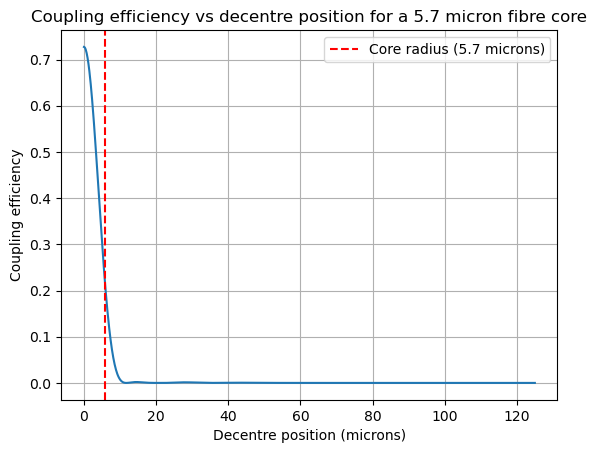

In [70]:
plt.plot(decentre_array_cladding*1e6, eta_psf_clad_5p7_decent_array)
plt.xlabel("Decentre position (microns)")
plt.ylabel("Coupling efficiency")
plt.title("Coupling efficiency vs decentre position for a 5.7 micron fibre core")
plt.axvline(5.7, color='r', linestyle='--', label='Core radius (5.7 microns)')
plt.legend()
plt.grid()

## Method 1: Monte Carlo Averaging

In [71]:
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import PchipInterpolator
from tqdm.auto import tqdm

In [72]:
# np.interp?

### Step 1 - set up Monte Carlo sampling for a perfectly positioned point source

In [ ]:
# Create NumPy's random-number generator.
# Setting a seed means that every time this cell is run,
# the same sequence of random numbers will be generated.
# This is useful while testing and debugging the calculation.
rng = np.random.default_rng(seed=49)

# Number of random jitter positions that will be simulated.
# Each sample represents one possible instantaneous position
# of the point-source PSF relative to its nominal position.
n_samples = 5000


In [90]:
# Note: RMS can be expressed as σ (sigma), but only if the mean error is exactly zero.

# convert the jitter FWHM to sigma for the Rayleigh distribution
jitter_rms_mas = 20

# Convert jitter from milliarcseconds to radians
sigma_theta_rad = jitter_rms_mas * 1e-3 / 206265

# Convert the jitter from angular units to linear units at the fibre plane
# Standard deviation (RMS) of the assumed jitter at the fibre plane.
sigma_jitter_fibre = Magnification * f_coude * sigma_theta_rad

print(
    f"One-axis RMS jitter at fibre plane: "
    f"{sigma_jitter_fibre * 1e6:.4f} µm"
)


One-axis RMS jitter at fibre plane: 3.8571 µm


### Step 2 - Generate random x- and y-jitter

In [91]:
# rng.normal?

In [92]:
# Draw n_samples of random jitter positions in the x and y direction, for a normal distribution with mean 0 and standard deviation sigma_jitter_fibre.
delta_x = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter x-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one x-displacement for each Monte Carlosample
)

# Assmuming jitter is isotropic, the y-displacements are drawn from the same distribution as the x-displacements.
delta_y = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter y-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one y-displacement for each Monte Carlosample
)

### Step 3 - Convert the 2D displacement into radial displacement

In [93]:
# Calculate the radial distance 
r_samples = np.sqrt(delta_x**2 + delta_y**2)

In [94]:
# For every random radial jitter position r_samples,
# estimate the corresponding point-source coupling efficiency from our previously calculated eta-versus-decentre curve.

# eta_samples = np.interp(
#     r_samples, # Positions where we WANT to know eta.
#     decentre_array_cladding, # Radial positions where eta was actually calculated using the optical overlap integral.
#     eta_psf_clad_5p7_decent_array # Coupling efficiencies calculated at those positions. 
#     )

# Construct a smooth interpolation function from the coupling
# efficiencies that were calculated at each radial decentre.
eta_interp = PchipInterpolator(
    decentre_array_cladding,
    eta_psf_clad_5p7_decent_array,
    extrapolate=False
)

# Evaluate the interpolated coupling efficiency at each
# randomly generated radial jitter displacement.
eta_samples = eta_interp(r_samples)

In [95]:
# Calculate the arithmetic mean of all sampled coupling efficiencies. 
eta_mean_MC = np.mean(eta_samples) 

# Display the resulting estimate of the mean coupling efficiency
# in the presence of jitter.
print(
    f"Mean jittered coupling efficiency = "
    f"{eta_mean_MC:.6f}"
)

Mean jittered coupling efficiency = 0.351459


In [ ]:
# Calculate the standard deviation of the individual coupling
# efficiencies sampled during the simulated jitter.
#
# This describes how much the instantaneous coupling varies
# because of the random pointing displacement.
eta_std = np.std(
    eta_samples, # Array of sampled coupling efficiencies.
    ddof=1 # Use the unbiased estimator for the standard deviation, which divides by (N-1) instead of N.
)


# Calculate the standard error of the Monte Carlo mean.
#
# This estimates the statistical uncertainty caused by using
# only a finite number of Monte Carlo samples.
#
# The uncertainty decreases approximately as 1/sqrt(N).
eta_mean_error = eta_std / np.sqrt(n_samples)


print(
    f"Mean coupling = "
    f"{eta_mean_MC:.6f} ± {eta_mean_error:.6f}"
)

Mean coupling = 0.351459 ± 0.003071


## Jitter with both x- and y-direction probability distiributions computed with Monte Carlo Averaging

In [97]:
x

array([[-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       ...,
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ]], shape=(1000, 1000))

In [98]:
y

array([[-0.000125  , -0.000125  , -0.000125  , ..., -0.000125  ,
        -0.000125  , -0.000125  ],
       [-0.00012475, -0.00012475, -0.00012475, ..., -0.00012475,
        -0.00012475, -0.00012475],
       [-0.0001245 , -0.0001245 , -0.0001245 , ..., -0.0001245 ,
        -0.0001245 , -0.0001245 ],
       ...,
       [ 0.0001245 ,  0.0001245 ,  0.0001245 , ...,  0.0001245 ,
         0.0001245 ,  0.0001245 ],
       [ 0.00012475,  0.00012475,  0.00012475, ...,  0.00012475,
         0.00012475,  0.00012475],
       [ 0.000125  ,  0.000125  ,  0.000125  , ...,  0.000125  ,
         0.000125  ,  0.000125  ]], shape=(1000, 1000))

In [99]:
img.shape

(1000, 1000)

In [102]:
r_max

0.000125

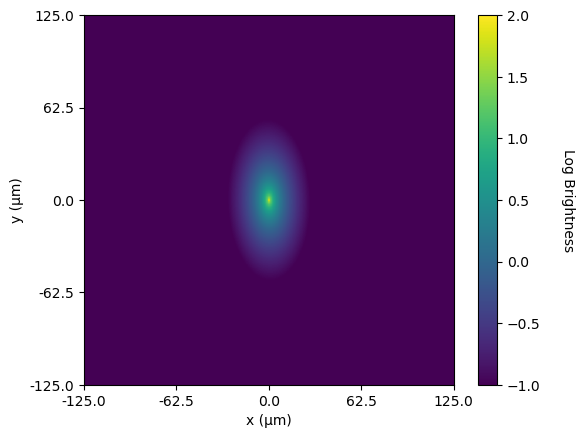

In [107]:
fig, ax = plt.subplots()
im = ax.imshow(
    log_img,
    origin="lower",
    interpolation="nearest",
    extent=[-r_max, r_max, -r_max, r_max],
    vmin=-1,
    vmax=2,
)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Log Brightness", rotation=270, labelpad=25)

ticks = np.linspace(-r_max, r_max, 5)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([f"{v*1e6:.1f}" for v in ticks])
ax.set_yticklabels([f"{v*1e6:.1f}" for v in ticks])

plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()

In [ ]:
# Build a smooth interpolation function for the previously calculated
# point-source coupling efficiency as a function of radial decentre.
#
# This replaces the np.interp step used previously to construct eta_psf_dr_map_2d.
# eta_psf_interp itself is NOT the 2D coupling map. It is a function that takes
# a radial distance r and returns the corresponding point-source coupling efficiency eta_psf(r).
#
# When eta_psf_interp is evaluated over a 2D array of radial distances,
# such as R = sqrt(x**2 + y**2), it produces the 2D point-source coupling map
# equivalent to the previously calculated eta_psf_dr_map_2d.

eta_psf_interp = PchipInterpolator(
    decentre_array_cladding, # Radial decentre positions where the coupling efficiency was calculated.
    eta_psf_clad_5p7_decent_array, # Coupling efficiencies calculated at those positions.
    extrapolate=False # Do not extrapolate beyond the range of the provided decentre positions.
)

In [118]:
# Calculate original extended source coupling
r_grid = np.sqrt(x**2 + y**2)

# # Point source coupling response at every position across the 2D grid
# eta_psf_2d = eta_psf_interp(r_grid)

In [137]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=49)

# Number of Monte carlo realisations
n_samples = 300

# print a sentence
print(f"The RMS jitter in fibre plane is, sigma_jitter_fibre: {sigma_jitter_fibre} metres")


The RMS jitter in fibre plane is, sigma_jitter_fibre: 3.857131152281451e-06 metres


In [138]:
# Random x-component of the image displacement

delta_x = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter x-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one x-displacement for each Monte Carlosample
)

# Random y-component of the image displacement
delta_y = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter y-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one y-displacement for each Monte Carlosample
)


In [139]:
# np.empty?

In [140]:
tqdm?

Init signature: tqdm(iterable=None, *args, **kwargs)
Docstring:      Asynchronous-friendly version of tqdm.
File:           ~/.conda/envs/oh_suppression_env/lib/python3.12/site-packages/tqdm/asyncio.py
Type:           type
Subclasses:     

In [141]:
# eta_extended_source_2d?

In [142]:
decentre_array_cladding.shape

(1000,)

In [157]:
eta_samples_20mas = np.empty(n_samples)

# This loop iterates over each Monte Carlo sample, applying a random jitter displacement to the extended source 
# image and calculating the resulting coupling efficiency.

for i in tqdm( 
    range(n_samples), # Iterate over the number of samples
    desc="Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging", # Description for the progress bar
): 

    # Calculate the radial distance of every point on the 2D grid from the jittered fibre centre position
    r_jittered = np.sqrt((x - delta_x[i])**2 + (y - delta_y[i])**2)

    # Start with zero coupling everywhere
    eta_map_jittered = np.zeros_like(r_jittered)

    # Find positions that lie within the range over which
    # eta_psf(r) was actually calculated
    inside_range = (
        r_jittered
        <= decentre_array_cladding[-1]
    )

    # Only interpolate where the point-source coupling
    # response has actually been calculated
    eta_map_jittered[inside_range] = eta_psf_interp(
        r_jittered[inside_range]
    )
    
    # Calculate the coupling efficiency
    eta_samples_20mas[i] = eta_extended_source_2d(
        eta_map_2d=eta_map_jittered, # 2D array of point source coupling efficiencies for this jittered position
        galaxy_brightness_2d=img, # 2D array of the extended source brightness distribution
        x_1d=x_1d, # 1D array of x-coordinates corresponding to the 2D grid
        y_1d=y_1d, # 1D array of y-coordinates
    )


Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging: 100%|██████████| 300/300 [00:08<00:00, 34.60it/s]


In [158]:
# Mean coupling efficiency over all jitter realizations
eta_mean_jitter_20mas = np.mean(eta_samples_20mas)

# Standard deviation of the instantaneous coupling efficiencies
eta_std_jitter_20mas = np.std(
    eta_samples_20mas,
    ddof=1
)

# Monte Carlo uncertainty on the estimated mean
eta_mean_error_20mas = (
    eta_std_jitter_20mas
    / np.sqrt(n_samples)
)

print(
    f"Mean jittered extended-source coupling efficiency = "
    f"{eta_mean_jitter_20mas:.6f}"
)

print(
    f"Standard deviation = "
    f"{eta_std_jitter_20mas:.6f}"
)

print(
    f"Monte Carlo error on mean = "
    f"{eta_mean_error_20mas:.6f}"
)

Mean jittered extended-source coupling efficiency = 0.098179
Standard deviation = 0.034662
Monte Carlo error on mean = 0.002001


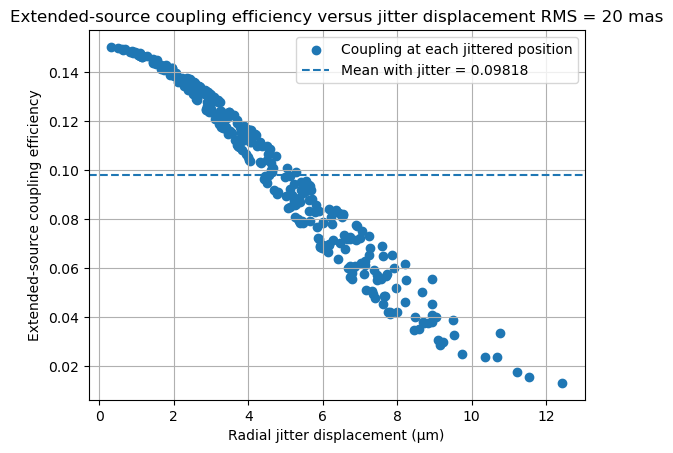

In [165]:
# Calculate the magnitude of each jitter displacement
jitter_displacement = np.sqrt(
    delta_x**2 + delta_y**2
)

plt.figure()

plt.scatter(
    jitter_displacement * 1e6,
    eta_samples_20mas,
    label="Coupling at each jittered position"
)

plt.axhline(
    eta_mean_jitter_20mas,
    linestyle="--",
    label=f"Mean with jitter = {eta_mean_jitter_20mas:.5f}"
)

plt.xlabel("Radial jitter displacement (µm)")

plt.ylabel("Extended-source coupling efficiency")

plt.title("Extended-source coupling efficiency versus jitter displacement RMS = 20 mas")

plt.grid()

plt.legend()

plt.show()

In [145]:
def sigma_jitter_milliarcsec_to_metres(sigma_jitter_rms, focal_length, demagnification): 
    """
    Convert the RMS jitter from milliarcseconds to metres at the fibre plane.

    Parameters: 
    sigma_jitter_rms : float
        RMS jitter in milliarcseconds.
    focal_length : float
        Focal length of the telescope in metres.
    demagnification : float 
        Demagnification factor from the telescope focal plane to the fibre plane, done by the reimaging optics. 

    Returns:
    float
        RMS jitter in metres at the fibre plane.
    """
    # Convert jitter from milliarcseconds to radians
    sigma_theta_radians = sigma_jitter_rms * 1e-3 / 206265 

    # Convert jitter from radians to physical units (metres) at the fibre plane using the focal length and demagnification

    sigma_jitter_metres = demagnification * focal_length * sigma_theta_radians

    return sigma_jitter_metres

In [171]:
eta_extended_source_2d?

Signature: eta_extended_source_2d(eta_map_2d, galaxy_brightness_2d, x_1d, y_1d)
Docstring:
Calculate the coupling efficiency of an incoherent extended source
into a fibre.

Parameters
----------
eta_map_2d : 2D array
    Point-source coupling efficiency evaluated across the x-y grid.

galaxy_brightness_2d : 2D array
    Linear galaxy brightness distribution evaluated on the same grid.

x_1d, y_1d : 1D arrays
    Coordinates of the x and y grid axes.

Returns
-------
eta_extended : float
    Brightness-weighted coupling efficiency of the extended source.
File:      ~/oh_suppression/codes/src/oh_suppression/extended_source_coupling.py
Type:      function

In [161]:
# Repeat experiment for RMS jitter of 10 mas

sigma_metre_10mas = sigma_jitter_milliarcsec_to_metres(10, f_coude, Magnification)
print(f"10 mas RMS jitter corresponds to {sigma_metre_10mas*1e6:.4f} µm at the fibre plane.")

eta_samples_10mas = np.empty(n_samples)


# Random x-component of the image displacement
delta_x_10mas = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter x-direction
    scale=sigma_metre_10mas, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one x-displacement for each Monte Carlosample
)

# Random y-component of the image displacement
delta_y_10mas = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter y-direction
    scale=sigma_metre_10mas, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one y-displacement for each Monte Carlosample
)

# This loop iterates over each Monte Carlo sample, applying a random jitter displacement to the extended source 
# image and calculating the resulting coupling efficiency.

for i in tqdm( 
    range(n_samples), # Iterate over the number of samples
    desc="Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging", # Description for the progress bar
): 

    # Calculate the radial distance of every point on the 2D grid from the jittered fibre centre position
    r_jittered = np.sqrt((x - delta_x_10mas[i])**2 + (y - delta_y_10mas[i])**2)

    # Start with zero coupling everywhere
    eta_map_jittered_10mas = np.zeros_like(r_jittered)

    # Find positions that lie within the range over which
    # eta_psf(r) was actually calculated
    inside_range = (
        r_jittered
        <= decentre_array_cladding[-1]
    )

    # Only interpolate where the point-source coupling
    # response has actually been calculated
    eta_map_jittered_10mas[inside_range] = eta_psf_interp(
        r_jittered[inside_range]
    )
    
    # Calculate the coupling efficiency
    eta_samples_10mas[i] = eta_extended_source_2d(
        eta_map_2d=eta_map_jittered_10mas, # 2D array of point source coupling efficiencies for this jittered position
        galaxy_brightness_2d=img, # 2D array of the extended source brightness distribution
        x_1d=x_1d, # 1D array of x-coordinates corresponding to the 2D grid
        y_1d=y_1d, # 1D array of y-coordinates
    )



10 mas RMS jitter corresponds to 1.9286 µm at the fibre plane.


Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging: 100%|██████████| 300/300 [00:07<00:00, 40.93it/s]


In [162]:
# Mean coupling efficiency over all jitter realizations
eta_mean_jitter_10mas = np.mean(eta_samples_10mas)

# Standard deviation of the instantaneous coupling efficiencies
eta_std_jitter_10mas = np.std(
    eta_samples_10mas,
    ddof=1
)

# Monte Carlo uncertainty on the estimated mean
eta_mean_error_10mas = (
    eta_std_jitter_10mas
    / np.sqrt(n_samples)
)

print(
    f"Mean jittered extended-source coupling efficiency = "
    f"{eta_mean_jitter_10mas:.6f}"
)

print(
    f"Standard deviation = "
    f"{eta_std_jitter_10mas:.6f}"
)

print(
    f"Monte Carlo error on mean = "
    f"{eta_mean_error_10mas:.6f}"
)

Mean jittered extended-source coupling efficiency = 0.130892
Standard deviation = 0.016467
Monte Carlo error on mean = 0.000951


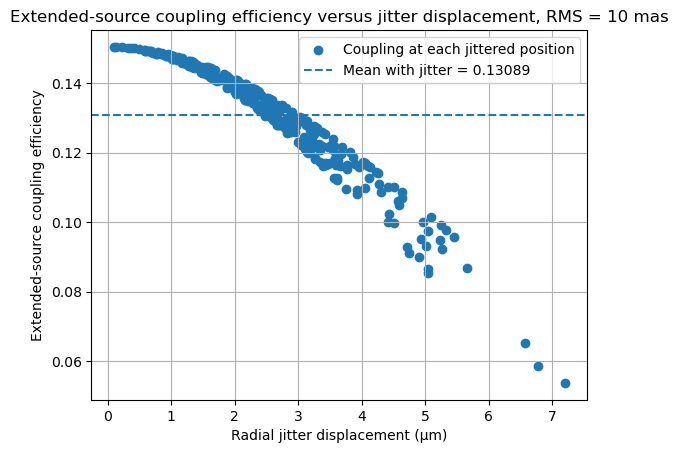

In [170]:
# Calculate the magnitude of each 10 mas jitter displacement
jitter_displacement_10mas = np.sqrt(
    delta_x_10mas**2 + delta_y_10mas**2
)

plt.figure()

plt.scatter(
    jitter_displacement_10mas * 1e6,
    eta_samples_10mas,
    label="Coupling at each jittered position"
)

plt.axhline(
    eta_mean_jitter_10mas,
    linestyle="--",
    label=f"Mean with jitter = {eta_mean_jitter_10mas:.5f}"
)

plt.xlabel("Radial jitter displacement (µm)")

plt.ylabel("Extended-source coupling efficiency")

plt.title(
    "Extended-source coupling efficiency versus jitter displacement, RMS = 10 mas"
)

plt.grid()

plt.legend()

plt.show()